In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
baseline_acc = accuracy_score(y_test, y_pred)

print(f"PCA nélkül → accuracy: {baseline_acc:.3f}")

PCA nélkül → accuracy: 0.972


In [5]:
components_list = [2, 5, 10, 20, 30, 40, 50, 64]
results = []

for n in components_list:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_pca, y_train)

    acc = accuracy_score(y_test, model.predict(X_test_pca))
    results.append(acc)

    print(f"{n} komponens → accuracy: {acc:.3f}")

2 komponens → accuracy: 0.517
5 komponens → accuracy: 0.819
10 komponens → accuracy: 0.886
20 komponens → accuracy: 0.944
30 komponens → accuracy: 0.961
40 komponens → accuracy: 0.961
50 komponens → accuracy: 0.972
64 komponens → accuracy: 0.972


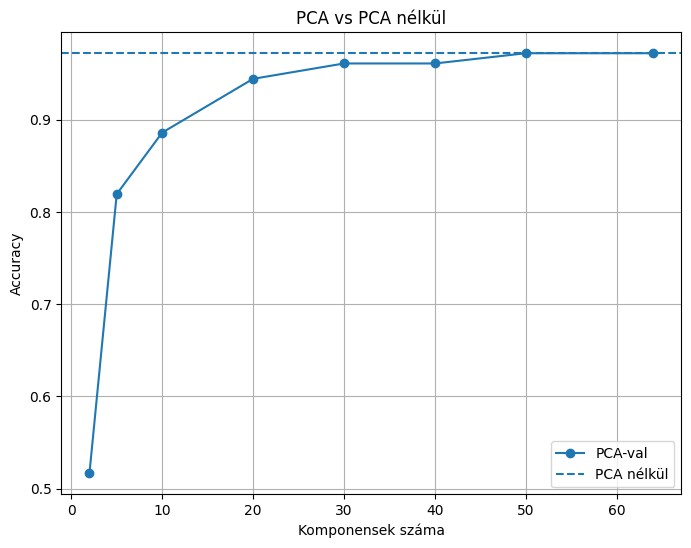

In [6]:
plt.figure(figsize=(8,6))

plt.plot(components_list, results, marker='o', label="PCA-val")
plt.axhline(y=baseline_acc, linestyle='--', label="PCA nélkül")

plt.xlabel("Komponensek száma")
plt.ylabel("Accuracy")
plt.title("PCA vs PCA nélkül")
plt.legend()
plt.grid()

plt.show()